In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds

import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

TensorFlow version: 2.21.0
PyTorch version: 2.13.0+cpu
CUDA available: False
Using CPU


In [5]:
data_dir = "../data/tfds"

print("Dataset directory:")
print(os.path.abspath(data_dir))

Dataset directory:
D:\AIML\WEEK4\Audio_Similarity_YAMNet\data\tfds


In [6]:
dataset, info = tfds.load(
    "speech_commands",
    split="train[:1%]",
    with_info=True,
    data_dir=data_dir
)

print("Dataset loaded successfully!")
print(dataset)

Dataset loaded successfully!
<_PrefetchDataset element_spec={'audio': TensorSpec(shape=(None,), dtype=tf.int16, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>


In [2]:
!pip install transformers torchaudio

In [7]:
print("Number of classes:")
print(info.features["label"].num_classes)

print("\nClass names:")
print(info.features["label"].names)

Number of classes:
12

Class names:
['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']


In [8]:
TARGET_SR = 16000

def preprocess_audio(audio):

    audio = np.asarray(audio).astype(np.float32)

    # Convert int16-style audio to approximately [-1, 1]
    if np.max(np.abs(audio)) > 1:
        audio = audio / 32768.0

    return audio

print("Preprocessing function created.")

Preprocessing function created.


In [11]:
# Select specific speech-command classes
target_classes = [
    "on",
    "off",
    "stop",
    "right",
    "left",
    "yes"
]

clips_per_class = 5

selected_clips = []

# Store selected examples by class
class_counts = {
    class_name: 0
    for class_name in target_classes
}

for example in tfds.as_numpy(dataset):

    label = int(example["label"])
    class_name = label_names[label]

    if class_name in target_classes:

        if class_counts[class_name] < clips_per_class:

            selected_clips.append({
                "audio": example["audio"],
                "label": label
            })

            class_counts[class_name] += 1

    # Stop once every class has enough clips
    if all(
        count == clips_per_class
        for count in class_counts.values()
    ):
        break

print("Selected clips:", len(selected_clips))
print("\nClass distribution:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Selected clips: 30

Class distribution:
on: 5
off: 5
stop: 5
right: 5
left: 5
yes: 5


In [12]:
label_names = info.features["label"].names

for i, clip in enumerate(selected_clips):

    print(
        f"Clip {i+1}: "
        f"Label = {clip['label']} "
        f"({label_names[clip['label']]})"
    )

Clip 1: Label = 4 (off)
Clip 2: Label = 5 (on)
Clip 3: Label = 7 (stop)
Clip 4: Label = 5 (on)
Clip 5: Label = 5 (on)
Clip 6: Label = 7 (stop)
Clip 7: Label = 4 (off)
Clip 8: Label = 2 (left)
Clip 9: Label = 7 (stop)
Clip 10: Label = 6 (right)
Clip 11: Label = 6 (right)
Clip 12: Label = 6 (right)
Clip 13: Label = 6 (right)
Clip 14: Label = 9 (yes)
Clip 15: Label = 2 (left)
Clip 16: Label = 9 (yes)
Clip 17: Label = 2 (left)
Clip 18: Label = 6 (right)
Clip 19: Label = 4 (off)
Clip 20: Label = 2 (left)
Clip 21: Label = 4 (off)
Clip 22: Label = 7 (stop)
Clip 23: Label = 4 (off)
Clip 24: Label = 7 (stop)
Clip 25: Label = 9 (yes)
Clip 26: Label = 9 (yes)
Clip 27: Label = 9 (yes)
Clip 28: Label = 2 (left)
Clip 29: Label = 5 (on)
Clip 30: Label = 5 (on)


In [13]:
# Select specific speech-command classes
target_classes = [
    "on",
    "off",
    "stop",
    "right",
    "left",
    "yes"
]

clips_per_class = 5

selected_clips = []

# Store selected examples by class
class_counts = {
    class_name: 0
    for class_name in target_classes
}

for example in tfds.as_numpy(dataset):

    label = int(example["label"])
    class_name = label_names[label]

    if class_name in target_classes:

        if class_counts[class_name] < clips_per_class:

            selected_clips.append({
                "audio": example["audio"],
                "label": label
            })

            class_counts[class_name] += 1

    # Stop once every class has enough clips
    if all(
        count == clips_per_class
        for count in class_counts.values()
    ):
        break

print("Selected clips:", len(selected_clips))
print("\nClass distribution:")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Selected clips: 30

Class distribution:
on: 5
off: 5
stop: 5
right: 5
left: 5
yes: 5


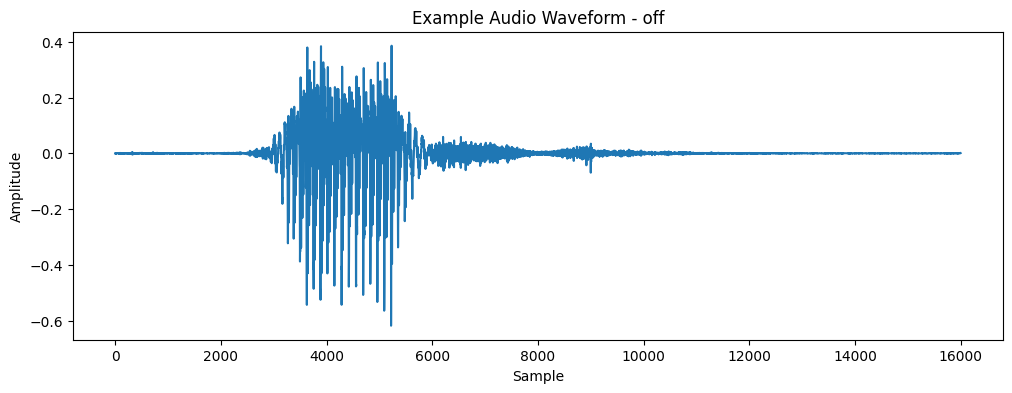

In [14]:
sample_audio = preprocess_audio(
    selected_clips[0]["audio"]
)

plt.figure(figsize=(12, 4))

plt.plot(sample_audio)

plt.title(
    f"Example Audio Waveform - "
    f"{label_names[selected_clips[0]['label']]}"
)

plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [15]:
model_name = "facebook/wav2vec2-base-960h"

processor = Wav2Vec2Processor.from_pretrained(
    model_name
)

wav2vec_model = Wav2Vec2Model.from_pretrained(
    model_name
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

wav2vec_model = wav2vec_model.to(device)

wav2vec_model.eval()

print("Wav2Vec2 loaded successfully!")
print("Model:", model_name)
print("Device:", device)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2 loaded successfully!
Model: facebook/wav2vec2-base-960h
Device: cpu


In [16]:
def extract_wav2vec_embedding(audio):

    # Preprocess waveform
    audio = preprocess_audio(audio)

    # Prepare input for Wav2Vec2
    inputs = processor(
        audio,
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    # Inference only
    with torch.no_grad():

        outputs = wav2vec_model(
            input_values
        )

    # Sequence of hidden representations
    hidden_states = outputs.last_hidden_state

    # Mean pooling across time
    clip_embedding = hidden_states.mean(
        dim=1
    )

    return clip_embedding.squeeze().cpu().numpy()

In [17]:
test_embedding = extract_wav2vec_embedding(
    selected_clips[0]["audio"]
)

print("Embedding shape:", test_embedding.shape)

print("\nFirst 10 embedding values:")
print(test_embedding[:10])

Embedding shape: (768,)

First 10 embedding values:
[-0.0529348  -0.00949552 -0.08905681 -0.07341678  0.05089642 -0.08379231
  0.02489053 -0.02869592  0.05016307 -0.23536602]


In [18]:
all_embeddings = []

for i, clip in enumerate(selected_clips):

    embedding = extract_wav2vec_embedding(
        clip["audio"]
    )

    all_embeddings.append(embedding)

    print(
        f"Processed clip {i+1}/"
        f"{len(selected_clips)}"
    )

all_embeddings = np.array(all_embeddings)

print("\nEmbedding matrix shape:")
print(all_embeddings.shape)

Processed clip 1/30
Processed clip 2/30
Processed clip 3/30
Processed clip 4/30
Processed clip 5/30
Processed clip 6/30
Processed clip 7/30
Processed clip 8/30
Processed clip 9/30
Processed clip 10/30
Processed clip 11/30
Processed clip 12/30
Processed clip 13/30
Processed clip 14/30
Processed clip 15/30
Processed clip 16/30
Processed clip 17/30
Processed clip 18/30
Processed clip 19/30
Processed clip 20/30
Processed clip 21/30
Processed clip 22/30
Processed clip 23/30
Processed clip 24/30
Processed clip 25/30
Processed clip 26/30
Processed clip 27/30
Processed clip 28/30
Processed clip 29/30
Processed clip 30/30

Embedding matrix shape:
(30, 768)


In [19]:
labels = np.array([
    clip["label"]
    for clip in selected_clips
])

label_text = [
    label_names[label]
    for label in labels
]

print("Labels:")
print(label_text)

Labels:
['off', 'on', 'stop', 'on', 'on', 'stop', 'off', 'left', 'stop', 'right', 'right', 'right', 'right', 'yes', 'left', 'yes', 'left', 'right', 'off', 'left', 'off', 'stop', 'off', 'stop', 'yes', 'yes', 'yes', 'left', 'on', 'on']


In [20]:
normalized_embeddings = normalize(
    all_embeddings,
    norm="l2"
)

print(
    "Normalized embedding shape:",
    normalized_embeddings.shape
)

first_magnitude = np.linalg.norm(
    normalized_embeddings[0]
)

print(
    "Magnitude of first normalized embedding:",
    first_magnitude
)

Normalized embedding shape: (30, 768)
Magnitude of first normalized embedding: 1.0


In [21]:
similarity_matrix = cosine_similarity(
    normalized_embeddings
)

print("Similarity matrix shape:")
print(similarity_matrix.shape)

print("\nFirst 5 × 5 values:")
print(similarity_matrix[:5, :5])

Similarity matrix shape:
(30, 30)

First 5 × 5 values:
[[0.9999999  0.9201954  0.92755115 0.92877024 0.9451752 ]
 [0.9201954  1.         0.9027461  0.9309726  0.90642875]
 [0.92755115 0.9027461  1.0000001  0.8912222  0.9388311 ]
 [0.92877024 0.9309726  0.8912222  0.9999999  0.932027  ]
 [0.9451752  0.90642875 0.9388311  0.932027   1.        ]]


In [22]:
distance_matrix = pairwise_distances(
    normalized_embeddings,
    metric="euclidean"
)

print("Distance matrix shape:")
print(distance_matrix.shape)

print("\nFirst 5 × 5 values:")
print(distance_matrix[:5, :5])

Distance matrix shape:
(30, 30)

First 5 × 5 values:
[[0.         0.39951158 0.38065422 0.37743774 0.33113384]
 [0.39951158 0.         0.4410308  0.37155712 0.43259984]
 [0.38065422 0.4410308  0.         0.46642926 0.34976813]
 [0.37743774 0.37155712 0.46642926 0.         0.36870825]
 [0.33113384 0.43259984 0.34976813 0.36870825 0.        ]]


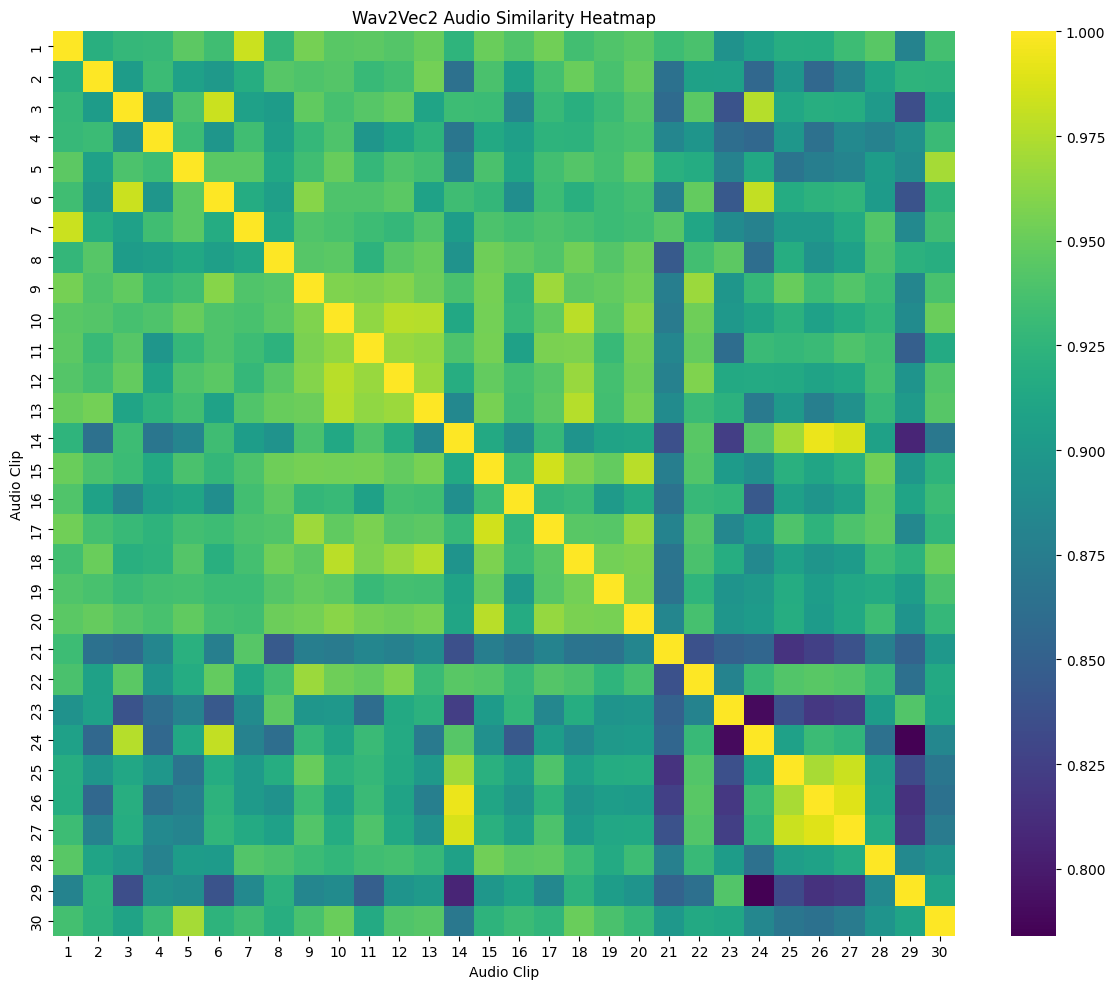

In [23]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    similarity_matrix,
    annot=False,
    cmap="viridis",
    xticklabels=range(1, 31),
    yticklabels=range(1, 31)
)

plt.title(
    "Wav2Vec2 Audio Similarity Heatmap"
)

plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.tight_layout()

plt.show()

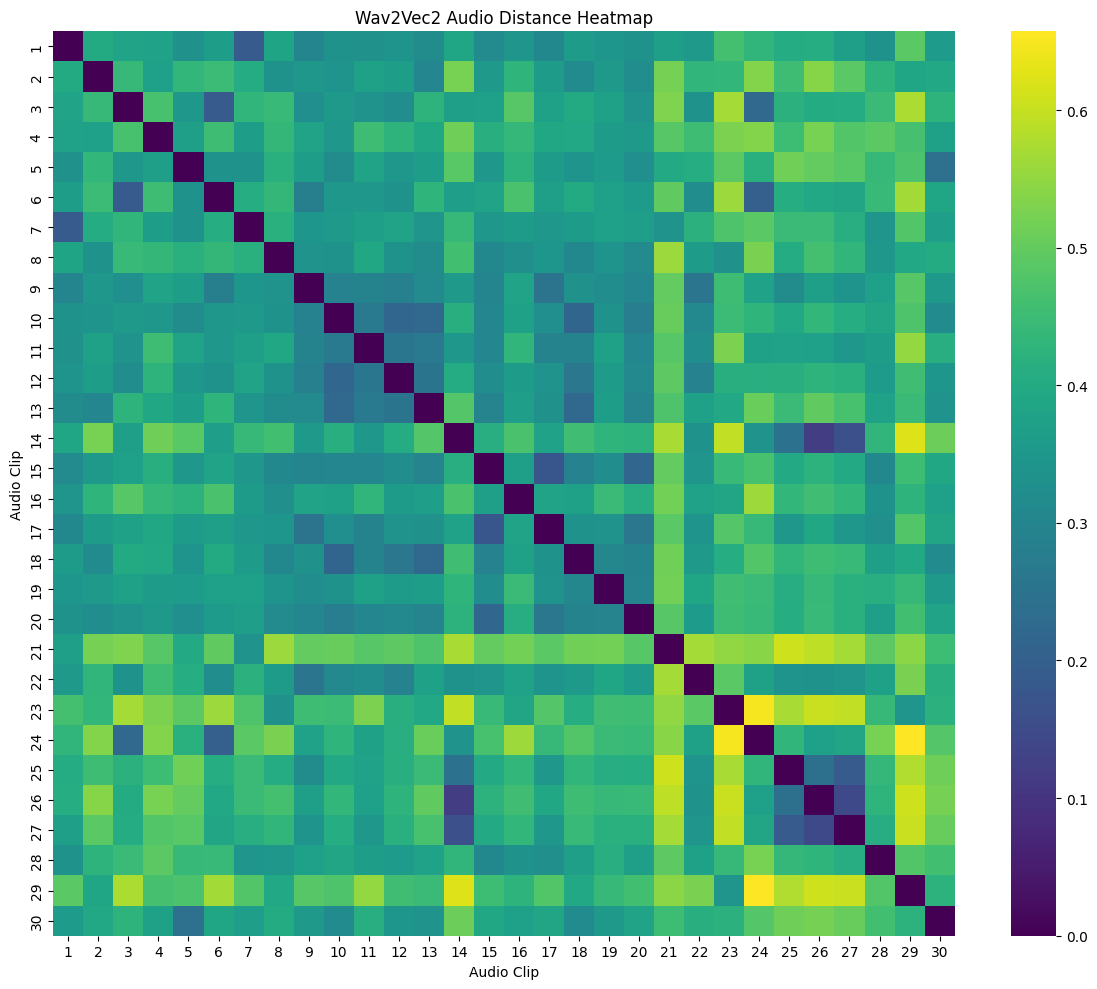

In [24]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    distance_matrix,
    annot=False,
    cmap="viridis",
    xticklabels=range(1, 31),
    yticklabels=range(1, 31)
)

plt.title(
    "Wav2Vec2 Audio Distance Heatmap"
)

plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.tight_layout()

plt.show()

In [25]:
same_class_mask = (
    labels[:, None] == labels[None, :]
)

different_class_mask = ~same_class_mask

# Remove self-comparisons
np.fill_diagonal(
    same_class_mask,
    False
)

np.fill_diagonal(
    different_class_mask,
    False
)

print(
    "Same-class pairs:",
    np.sum(same_class_mask)
)

print(
    "Different-class pairs:",
    np.sum(different_class_mask)
)

Same-class pairs: 120
Different-class pairs: 750


In [26]:
same_class_similarity = similarity_matrix[
    same_class_mask
]

different_class_similarity = similarity_matrix[
    different_class_mask
]

same_class_distance = distance_matrix[
    same_class_mask
]

different_class_distance = distance_matrix[
    different_class_mask
]

print(
    "Average same-class similarity:",
    same_class_similarity.mean()
)

print(
    "Average different-class similarity:",
    different_class_similarity.mean()
)

print(
    "Average same-class distance:",
    same_class_distance.mean()
)

print(
    "Average different-class distance:",
    different_class_distance.mean()
)

Average same-class similarity: 0.94373715
Average different-class similarity: 0.9135733
Average same-class distance: 0.3197298
Average different-class distance: 0.40878695


In [27]:
results = pd.DataFrame({
    "Metric": [
        "Number of audio clips",
        "Embedding dimension",
        "Similarity matrix size",
        "Distance matrix size",
        "Average same-class similarity",
        "Average different-class similarity",
        "Average same-class distance",
        "Average different-class distance"
    ],

    "Value": [
        len(selected_clips),
        all_embeddings.shape[1],
        str(similarity_matrix.shape),
        str(distance_matrix.shape),
        round(
            same_class_similarity.mean(),
            4
        ),
        round(
            different_class_similarity.mean(),
            4
        ),
        round(
            same_class_distance.mean(),
            4
        ),
        round(
            different_class_distance.mean(),
            4
        )
    ]
})

results

,Metric,Value
0,Number of audio clips,30
1,Embedding dimension,768
2,Similarity matrix size,"(30, 30)"
3,Distance matrix size,"(30, 30)"
4,Average same-class similarity,0.9437
5,Average different-class similarity,0.9136
6,Average same-class distance,0.3197
7,Average different-class distance,0.4088


In [28]:
similarity_gap = (
    same_class_similarity.mean()
    - different_class_similarity.mean()
)

distance_gap = (
    different_class_distance.mean()
    - same_class_distance.mean()
)

print(
    "Similarity separation gap:",
    round(similarity_gap, 4)
)

print(
    "Distance separation gap:",
    round(distance_gap, 4)
)

Similarity separation gap: 0.0302
Distance separation gap: 0.0891
